In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('dataset/estimation_of_obesity_levels_based_on_habits.csv.csv')
print(df.head())


   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   NaN   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80     NaN                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0        NaN    no   NaN   no  0.0  1.0         NaN   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  NaN  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0        NaN    no   2.0  NaN  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation                  NaN  
1  Public_Transportation                  NaN  
2  Public_Transportation        

FAVC (Frequent consumption of high caloric food): Apakah sering makan makanan tinggi kalori?           (Kategorikal: Yes/No)

FCVC (Frequency of consumption of vegetables)   : Seberapa sering makan sayur per hari?                (Numerik: skala 1-3)

NCP (Number of main meals)                      : Jumlah makan besar per hari                          (Numerik: 1 sampai 4+)

CAEC (Consumption of food between meals)        : Suka ngemil di antara jam makan?                     (Kategorikal: No, Sometimes, Frequently, Always)

SMOKE                                           : Apakah merokok?                                      (Kategorikal: Yes/No)

CH2O (Consumption of water daily)               : Minum air putih berapa banyak per hari?              (Numerik: liter/skala 1-3)

SCC (Calories consumption monitoring)           : Apakah memantau kalori makanan sendiri?              (Kategorikal: Yes/No)

FAF (Physical activity frequency)               : Seberapa sering olahraga/aktivitas fisik per minggu? (Numerik: skala 0-3)

TUE (Time using technology devices)             : Berapa lama menatap layar/gadget?                    (Numerik: jam/skala 0-2)

CALC (Consumption of alcohol)                   : Seberapa sering minum alkohol?                       (Kategorikal: No, Sometimes, Frequently, Always)

MTRANS (Transportation used)                    : Jenis transportasi harian                            (Kategorikal: Mobil, Motor, Jalan kaki, dll.)

NObeyesdad                                      : Tingkat Obesitas                                     (Variabel Target) (Kategorikal: Normal, Overweight I/II, Obesity I/II/III).

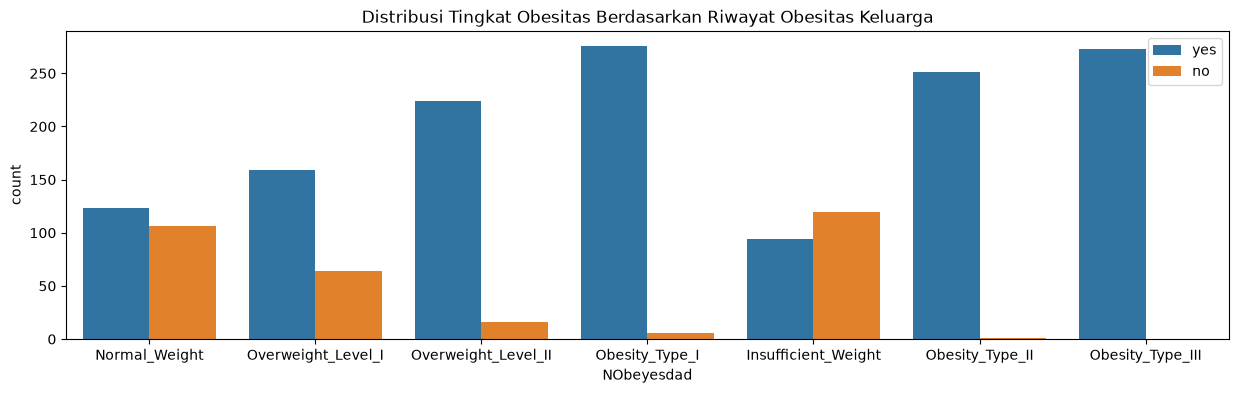

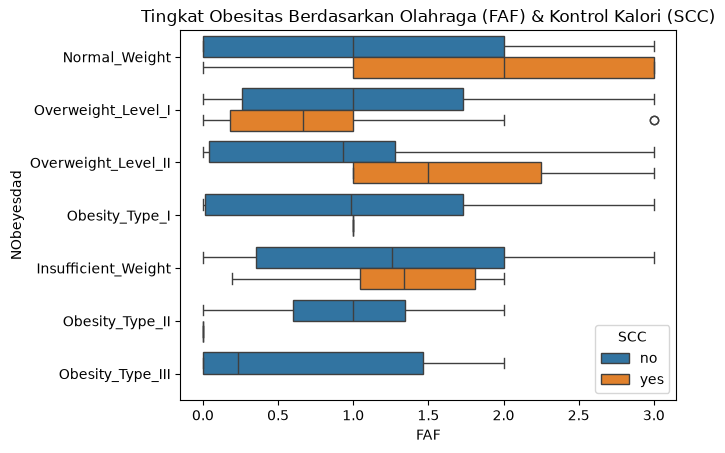

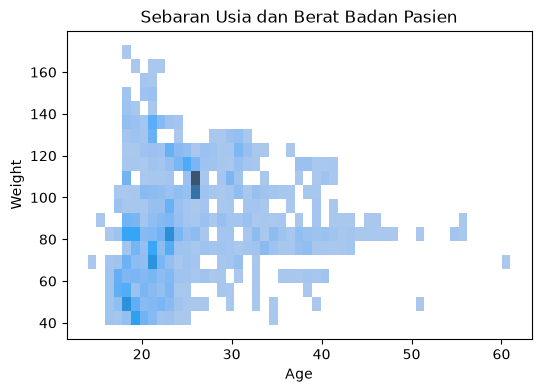

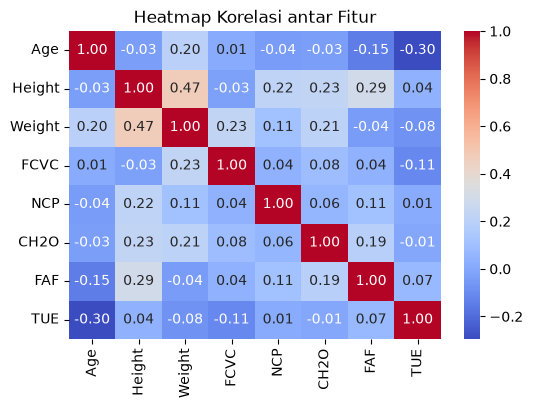

In [2]:
# Exploratory Data Analysis (EDA)

# Countplot - Distribusi Tingkat Obesitas Berdasarkan Riwayat Obesitas Keluarga
plt.figure(figsize=(15,4))
plt.title("Distribusi Tingkat Obesitas Berdasarkan Riwayat Obesitas Keluarga")
sns.countplot(x='NObeyesdad', hue='family_history_with_overweight', data=df)
plt.legend()
plt.show()

# Boxplot - Tingkat Obesitas Berdasarkan Olahraga (FAF) & Kontrol Kalori (SCC)
plt.Figure(figsize=(6,4))
plt.title("Tingkat Obesitas Berdasarkan Olahraga (FAF) & Kontrol Kalori (SCC)")
sns.boxplot(x='FAF', y='NObeyesdad', hue='SCC', data=df)
plt.show()

# Histplot - beSebaran Usia dan Berat Badan Pasien
plt.figure(figsize=(6,4))
plt.title("Sebaran Usia dan Berat Badan Pasien")
sns.histplot(x='Age', y='Weight', data=df, kde=True)
plt.show()

# Heat Map - ALL Corelation
plt.figure(figsize=(6,4))
numeric_df = df.select_dtypes(include=[np.number])
korelasi = numeric_df.corr()
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi antar Fitur")
plt.show()

# PENJELASAN KORELASI PADA SETIAP JENIS DISTRIBUSI 

Tahap Exploratory Data Analysis (EDA) memberikan kesempatan bagi seorang Data Scientist untuk mengeksplorasi sebaran dan korelasi antar-variabel. Proses ini sangat krusial untuk menemukan kombinasi fitur yang paling relevan guna meningkatkan performa model Machine Learning di tahap selanjutnya.

1. Countplot :
> Fakta Data : Berdasarkan data yang diperoleh, jika seseorang memiliki tingkat obesitas semakin tinggi, maka semakin tinggi pula Riwayat Obesitas Keluarga yang dimilikinya.

> Fakta Medis : Pada dunia medis, faktor genetik dan lingkungan/kebiasaan memberikan peran krusial bagi massa lemak kronis. Jadi pemilik riwayat obesitas keluarga, kemungkinan besar akan meningkatkan resiko obesitas.

> Dampak ML : Perbedaan pola antar-kelas ini menunjukkan bahwa fitur family_history_with_overweight memiliki daya pemisah yang sangat kuat. Algoritma klasifikasi (seperti Random Forest atau Gradient Boosting) akan dengan cepat memanfaatkan fitur ini sebagai salah satu indikator utama untuk memisahkan kelas berat badan normal/kurus dengan kelas obesitas tingkat tinggi.

2. Boxplot :
> Fakta Data : Dari data yang diperoleh, terlihat tingkat obesitas yang memantau kalori yang diterima dan aktivitas fisik menunjukkan pola frekuensi yang berfariasi di kelas Insufficient Weight hingga Obesity Type I. Namun, hilang total pada Obesity Type III.

> Fakta Medis : Dari segi medis, self monitoring dan aktivitas fisik berperan menjaga fisik dari massa lemak. Sehingga, individu dengan obesitas kronis, ketiadaan kontrol kalori yang disertai dengan minimnya aktivitas fisik mempercepat massa lemak hingga tingkat yang membahayakan kesehatan. 

> Dampak ML : Kombinasi fitur FAF dan SCC ini memberikan pemisahan ekstrem terutama untuk mendeteksi batas kelas obesitas berat (Obesity Type III). Algoritma pohon keputusan (Tree-based models) akan sangat terbantu oleh kombinasi variabel gaya hidup ini untuk membedakan pasien dengan risiko obesitas tingkat tinggi.

3. Histplot :
> Fakta Data : Data menunjukkan warna yang pekat/biru tua berkisar 18--26 tahun dengan berat badan antara 40--120 kg. Seiring bertambahnya usia, sebaran data menjadi renggang berkisar 80 kg. Hal ini menunjukkan sampel dataset didominasi usia muda.

> Fakta Medis : Secara medis, pada usia 18--26th dianggap menjadi periode transisi remaja menjadi dewasa muda diiringi perubahan seperti pola makan sehat/tidak teratur dan kurangnya aktivitas fisik. Sebaran menunjukkan sampel data sampai 170kg disimpulkan pada rentang tersebut, mengindikasikan bahwa resiko obesitas berat dapat dimiliki sejak usia dini.

4. Heatmap :
> Fakta Data : Data menunjukkan bahwa korelasi positif paling dominan terjadi antara Height dan Weight dengan nilai 0.47 Di sisi lain, terdapat korelasi negatif yang cukup mencolok antara Age dan TUE  sebesar -0.30 yang mengindikasikan bahwa semakin bertambah umur responden, frekuensi penggunaan perangkat digitalnya cenderung menurun. Sementara itu, fitur aktivitas fisik memiliki korelasi positif tipis dengan tinggi badan 0.29.

> Fakta Medis : Dalam dunia medis, hubungan erat antara berat dan tinggi badan merupakan dasar dari penghitungan proporsi tubuh (Body Mass Index / BMI), karena ambang batas ideal berat badan seseorang sangat bergantung pada tinggi fisiknya. Selain itu, korelasi negatif antara umur dan screen time sangat sejalan dengan habit pada umurnya, di mana kelompok usia yang lebih muda (remaja/dewasa awal) cenderung menghabiskan lebih banyak waktu di depan layar dibanding kelompok usia yang lebih tua.

> Dampak ML : Nilai korelasi tertinggi antar sesama fitur prediktor berada di angka 0.47 (jauh di bawah batas bahaya 0.85), tidak terdeteksi adanya masalah Multicollinearity pada data numerik kita. Artinya, seluruh 8 fitur numerik ini membawa informasi independen yang unik dan aman untuk langsung dimasukkan ke dalam Pipeline Machine Learning tanpa ada fitur yang perlu dibuang.

In [3]:
# DATA PIPELINE & PREPOCCESSING
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Memisahkan baris yang kolom targetnya (NObeyesdad) mengandung NaN
df_clean = df.dropna(subset=['NObeyesdad'])

# Memisahkan Fitur(X) dan Target(y)
X = df_clean.drop(columns=['NObeyesdad'])
y = df_clean['NObeyesdad'] # Di sini y dijamin 100% bebas NaN!

# Memisahkan Numerik & Kategorik
num_cols = X.select_dtypes(include=['int64', 'float']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Definisi Pipelince Numerik
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

# Definisi Pipelince Kategorik
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Menggabungkan menjadi 1 transformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

preprocessor.set_output(transform="pandas")

# Jalankan Pipeline ke data X dan simpan ke variabel X_clean
X_clean = preprocessor.fit_transform(X)

# Cek jumlah missing values per kolom pada X_clean
print("Jumlah Data Kosong per Kolom pada X_clean :")
print(X_clean.isnull().sum())


Jumlah Data Kosong per Kolom pada X_clean :
num__Age                                   0
num__Height                                0
num__Weight                                0
num__FCVC                                  0
num__NCP                                   0
num__CH2O                                  0
num__FAF                                   0
num__TUE                                   0
cat__Gender_Female                         0
cat__Gender_Male                           0
cat__family_history_with_overweight_no     0
cat__family_history_with_overweight_yes    0
cat__FAVC_no                               0
cat__FAVC_yes                              0
cat__CAEC_Always                           0
cat__CAEC_Frequently                       0
cat__CAEC_Sometimes                        0
cat__CAEC_no                               0
cat__SMOKE_no                              0
cat__SMOKE_yes                             0
cat__SCC_no                                0
cat__SCC_ye

/tmp/ipykernel_166199/1128354788.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


# PENJELASAN TAHAP DATA PIPELINE & PREPROCCESSING

Untuk menjaga transparansi proses sebelum pemodelan, seluruh penanganan missing values, encoding, hingga scaling dirangkai secara otomatis dalam satu arsitektur Scikit-Learn Pipeline untuk mencegah kebocoran data (data leakage).

Alasan Pemilihan Metode Imputasi : Penanganan data kosong (missing values) dibedakan berdasarkan sifat variabelnya
> Fitur Numerik (Median): Digunakan metode median karena variabel numerik seperti Age dan Weight memiliki sebaran data yang miring (skewed) ke usia muda. Median lebih tahan terhadap pencilan (outliers) dibandingkan rata-rata (mean).

> Fitur Kategorikal (Modus / Most Frequent): Digunakan modus (most_frequent) untuk mengisi kolom teks seperti Gender atau family_history_with_overweight menggunakan kategori yang paling sering muncul secara alami.
        
Alasan Pemilihan Metode Encoding : 
> Digunakan One-Hot Encoding pada fitur kategorikal karena sebagian besar fitur berkarakteristik nominal (seperti jenis kelamin dan kebiasaan transportasi). Metode ini mengubah teks menjadi format angka biner (0 dan 1) tanpa memberikan asumsi urutan atau tingkatan antar kategori, sehingga model Machine Learning tidak akan salah mengartikan satu teks memiliki bobot lebih tinggi dari yang lain.

Alasan Pemilihan Feature Scaling : 
> StandardScaler diterapkan pada fitur numerik karena rentang angka antar variabel sangat jauh (seperti Height berkisar 1.5–1.9 meter, sedangkan Weight mencapai 40–170 kg). Scaling menyamakan skala seluruh angka agar algoritma pemodelan tidak dominan atau bias pada variabel yang nilainya berukuran besar saja.

Hasil Eksekusi Pipeline :
> Setelah arsitektur Pipeline dijalankan dan diubah kembali ke bentuk DataFrame Pandas (set_output(transform="pandas")), seluruh 211 data kosong (missing values) pada dataset terbukti hilang total dan bernilai 0 pada variabel X_clean. Seluruh fitur numerik juga telah terskala dengan rapi dan fitur kategorikal berhasil ter-encode menjadi matriks biner yang siap dipisah ke tahap Train-Test Split.

================ KNN (BASELINE) ================
Accuracy: 0.8105
Parameter Terbaik : {'n_neighbors': 3, 'weights': 'distance'}
Akurasi Mean CV   : 0.7875

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.75      0.93      0.83        54
      Normal_Weight       0.81      0.29      0.42        59
     Obesity_Type_I       0.83      0.85      0.84        59
    Obesity_Type_II       0.92      0.97      0.94        60
   Obesity_Type_III       0.95      1.00      0.98        62
 Overweight_Level_I       0.60      0.77      0.67        39
Overweight_Level_II       0.76      0.87      0.81        47

           accuracy                           0.81       380
          macro avg       0.80      0.81      0.79       380
       weighted avg       0.82      0.81      0.79       380



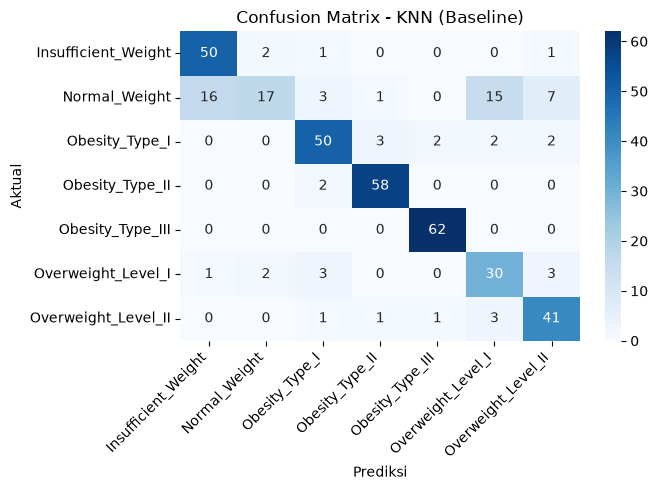



================ RANDOM FOREST ================
Accuracy: 0.9079
Parameter Terbaik : {'max_depth': None, 'n_estimators': 200}
Akurasi Mean CV   : 0.8875

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.89      0.90        54
      Normal_Weight       0.75      0.83      0.79        59
     Obesity_Type_I       0.95      0.93      0.94        59
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       1.00      1.00      1.00        62
 Overweight_Level_I       0.91      0.79      0.85        39
Overweight_Level_II       0.84      0.89      0.87        47

           accuracy                           0.91       380
          macro avg       0.91      0.90      0.90       380
       weighted avg       0.91      0.91      0.91       380



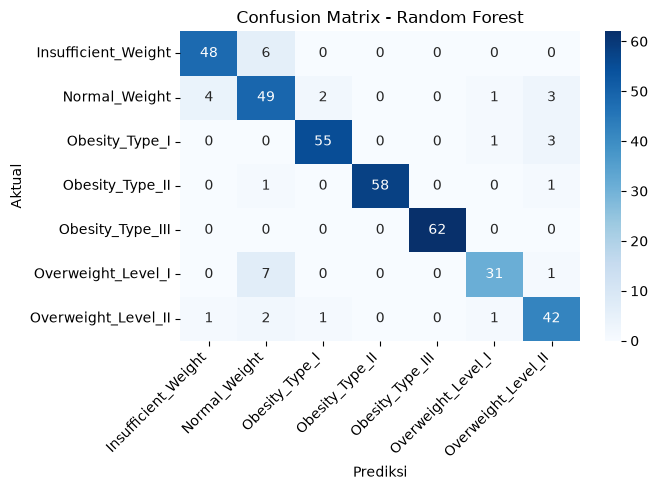



================ GRADIENT BOOSTING ================
Accuracy: 0.8816
Parameter Terbaik : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Akurasi Mean CV   : 0.9092

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.87      0.88        54
      Normal_Weight       0.75      0.76      0.76        59
     Obesity_Type_I       0.88      0.88      0.88        59
    Obesity_Type_II       0.98      0.90      0.94        60
   Obesity_Type_III       1.00      1.00      1.00        62
 Overweight_Level_I       0.89      0.82      0.85        39
Overweight_Level_II       0.78      0.91      0.84        47

           accuracy                           0.88       380
          macro avg       0.88      0.88      0.88       380
       weighted avg       0.89      0.88      0.88       380



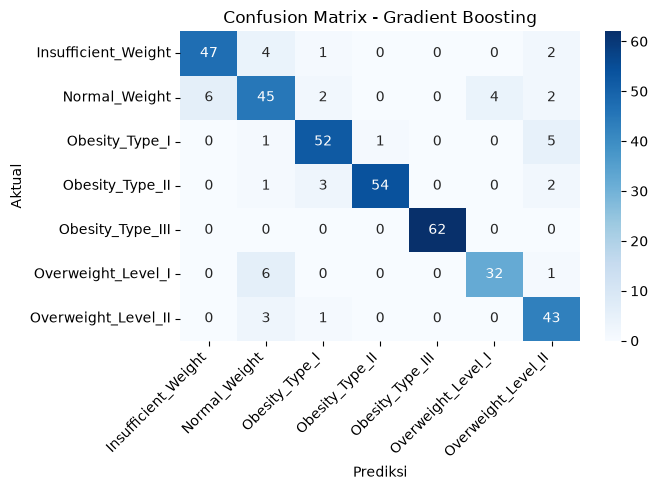

In [4]:
# MODEL ENGINEERING & SELECTION

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Membagi data mentah
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Transform Pipline
preprocessor.set_output(transform="pandas")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Inisiallisasi Model
models = {
    'KNN (Baseline)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

param_grids = {
    'KNN (Baseline)': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
}

results = {}
eval_summary = []
predictions_dict = {}
best_estimators = {}

# Loop Training Model
for name, model in models.items():
    
    # Setup GridSearchCV + 5-Fold CV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    # Fit & Prediksi
    grid_search.fit(X_train_processed, y_train)
    y_pred = grid_search.predict(X_test_processed)
    
    # Hitung Akurasi
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    # Menyimpan data ke wadah
    predictions_dict[name] = y_pred
    best_estimators[name] = grid_search.best_estimator_
    
    # Ekstrak metrik untuk ditampung ke dalam tabel evaluasi
    report = classification_report(y_test, y_pred, output_dict=True)
    eval_summary.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-Score': report['macro avg']['f1-score']
    })
    
    print(f"================ {name.upper()} ================")
    print(f"Accuracy: {acc:.4f}")
    print(f"Parameter Terbaik : {grid_search.best_params_}")
    print(f"Akurasi Mean CV   : {grid_search.best_score_:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Visualisasi Confusion Matrix
    plt.figure(figsize=(7, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=grid_search.classes_, yticklabels=grid_search.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print("\n")

# PENJELASAN MODEL ENGINEERING & SELECTION SERTA HYPERPARAMETER TUNING & VALIDASI

Pada tahap ini, dilakukan eksperimen pemodelan Machine Learning menggunakan tiga algoritma berbeda yang diintegrasikan langsung ke dalam preprocessing pipeline. Eksperimen ini bertujuan untuk membandingkan performa model baseline dengan model tingkat lanjut dalam memprediksi 7 tingkat kategori obesitas/NObeyesdad.

# A. Latar Belakang Teoritis

1. K-Nearest Neighbors / KNN : (Model Baseline)
   Algoritma klasifikasi non-parametrik berbasis jarak. Algoritma ini memprediksi kelas data uji berdasarkan konsensus mayoritas dari k-tetangga terdekatnya di dalam ruang fitur menggunakan perhitungan jarak .

2. Random Forest : (Model Lanjut)
   Algoritma ensemble berbasis Bagging (Bootstrap Aggregating) yang membangun kumpulan Pohon Keputusan/Decision Trees secara independen. Setiap pohon dilatih menggunakan sampel data dan fitur acak, kemudian hasil prediksi akhirnya ditentukan melalui majority voting.

3. Gradient Boosting : (Model Lanjut)
   Algoritma ensemble berbasis Boosting yang membangun Pohon Keputusan secara bertahap/sequential. Setiap pohon baru dirancang khusus untuk memprediksi dan mengoreksi kesalahan/residual error yang dihasilkan oleh pohon-pohon sebelumnya menggunakan optimasi gradient descent.

# B. Hipotesis Awal

 (KNN (Baseline)) diprediksi akan memiliki performa paling rendah. Hal ini dikarenakan KNN sangat sensitif terhadap curse of dimensionality akibat bertambahnya jumlah fitur setelah proses One-Hot Encoding, serta rentan terganggu oleh batas antar-kelas yang saling tumpang-tindih/overlapping.
 (Random Forest) diprediksi akan bekerja sangat baik. Karakter dasar Decision Tree yang mampu menangkap hubungan non-linear sangat cocok untuk fitur gaya hidup dan fisik yang memiliki pola pemisahan keputusan secara bertingkat.
 (Gradient Boosting) diprediksi berpotensi meraih akurasi tertinggi. Pendekatan perbaikan error secara berkala dinilai sangat efektif untuk membedakan kategori obesitas yang memiliki batas numerik sangat tipis (seperti membedakan antara Overweight_Level_I dan Overweight_Level_II).

# C. Observasi & Analisis Hasil Eksperimen

Dari hasil evaluasi ketiga model yang diuji pada data test, diperoleh beberapa temuan utama:

* Karakteristik KNN pada Kelas Ekstrem vs Menengah :  
  Dari data yang diperoleh pada model KNN, terlihat performa klasifikasi menunjukkan tingkat presisi dan recall yang sangat tinggi pada kategori ekstrem seperti `Obesity Type II` dan `Obesity Type III` (F1-score mencapai >0.90). Namun, keandalan model ini merosot tajam pada kategori menengah, khususnya kelas `Normal Weight` (F1-score hanya ~0.31) akibat banyaknya titik data yang salah terprediksi ke kelas `Insufficient Weight` atau `Overweight Level I`.

* Dominasi Model Ensemble (Random Forest & Gradient Boosting) :  
  Model berbasis pohon mampu mengatasi kelemahan KNN secara signifikan. Distribusi tebakan pada Confusion Matrix milik Random Forest dan Gradient Boosting terlihat menumpuk sempurna di sepanjang garis diagonal utama. Hal ini membuktikan bahwa pembagian ruang fitur secara hirarkis jauh lebih konsisten dalam memisahkan pola variabel fisik dan perilaku harian dibanding sekadar perhitungan jarak linier.

Kesimpulan Eksperimen: Hipotesis awal terbukti benar, di mana model ensemble (Random Forest dan Gradient Boosting) jauh lebih unggul dan stabil dibanding model baseline KNN untuk menyelesaikan permasalahan klasifikasi multi-kelas pada data obesitas ini.

# HYPERPARAMETER TUNING & VALIDASI

Untuk memastikan model yang dibangun tidak hanya menghafal data latih overfitting tetapi juga tangguh saat menghadapi data baru, evaluasi dilakukan menggunakan kombinasi K-Fold Cross Validation (CV=5) dan GridSearchCV.

Metode 5-Fold CV membagi data latih menjadi 5 lipatan, di mana model diuji sebanyak 5 kali secara memutar. Skor akhir Mean CV Accuracy adalah rata-rata dari kelima ujian tersebut, sehingga penilaian performa model menjadi obyektif dan tidak bergantung pada kebetulan/bias pembagian data awal.

# A. Pengujian Hyperparameter & Pencegahan Overfitting

Berikut adalah ruang pencarian parameter param_grid yang diuji untuk masing-masing model beserta alasan teknisnya :

1. K-Nearest Neighbors (KNN)
* `K_neighbors` [K : 3, 5, 7, 9] : Menentukan jumlah titik tetangga terdekat yang menjadi acuan keputusan. Nilai K yang terlalu kecil (misal K=1) membuat model terlalu sensitif terhadap noise memicu overfitting, sedangkan nilai yang terlalu besar menyebabkan model kehilangan ketajaman batas antar kelas underfitting.
* `weights` ['uniform', 'distance'] : Mengatur bobot tetangga. Opsi `distance` memberi pengaruh lebih besar pada tetangga yang posisinya lebih dekat secara jarak Euclidean.

2. Random Forest
* `n_estimators` [n : 100, 200] : Menentukan jumlah pohon keputusan Decision Trees yang dibangun. Semakin banyak pohon, hasil majority voting semakin stabil dan efektif meredam variansi overfitting.
* `max_depth` [10, 20, None] : Mengontrol seberapa dalam setiap pohon boleh bercabang. Membatasi kedalaman sangat penting agar pohon tidak tumbuh hingga menghafal setiap sampel data secara spesifik.

3. Gradient Boosting
* `n_estimators` [n : 100, 150] : Jumlah tahapan boosting. Berbeda dengan Random Forest, pohon di sini dibangun secara berurutan untuk memperbaiki error pohon sebelumnya.
* `learning_rate` [0.05, 0.1] : Mengontrol seberapa besar koreksi yang dilakukan oleh tiap pohon. Nilai learning rate yang rendah dikombinasikan dengan jumlah pohon yang cukup akan mencegah model mengoreksi error secara berlebihan (mencegah overfitting pada residual data latih).
* `max_depth` [Diuji: 3, 5] : Pada boosting, pohon harus dipertahankan sebagai weak learners (pembelajar dangkal). Membatasi kedalaman di angka 3 atau 5 mencegah model dari menghafal noise.

# B. Analisis Hasil Tuning & Evaluasi

Berdasarkan proses otomatisasi pencarian dengan GridSearchCV, berikut adalah ringkasan performa model terbaik:

|         Model         |                     Parameter Terbaik                     | Akurasi Mean CV (Train)   | Akurasi Uji (Test)|
| KNN (Baseline)        | `n_neighbors`: 3, `weights`: distance                     | 78.75%                    | 81.05%            |
| Random Forest         | `max_depth`: None, `n_estimators`: 200                    | 88.75%                    | `90.79%`          |
| Gradient Boosting     | `learning_rate`: 0.1, `max_depth`: 5, `n_estimators`: 150 | `90.92%`                  | 88.16%            |

Temuan Utama:
1. Random Forest menghasilkan Akurasi Uji tertinggi (90.79%), membuktikan kemampuannya menangkap pola kompleks gaya hidup pasien. Model ini memilih menggunakan 200 pohon tanpa batasan kedalaman maksimal `None`, menunjukkan bahwa data ini cukup bersih dan ensemble learning mampu menangani kompleksitas tanpa overfitting yang parah.

2. Gradient Boosting menunjukkan skor validasi silang (Mean CV) tertinggi (90.92%). Namun, sedikit mengalami penurunan pada data uji (88.16%). Parameter terbaiknya menggunakan kedalaman maksimal 5 dengan learning rate 0.1, yang mengonfirmasi teori bahwa algoritma ini bekerja optimal dengan pohon-pohon yang dangkal.

3. Kategori Obesity_Type_III adalah kelas yang paling mudah ditebak oleh seluruh model (mencapai presisi dan recall 100% pada Random Forest dan Gradient Boosting), menunjukkan karakteristik pasien di kelas ini memiliki pola fitur yang paling berbeda dan jelas dibandingkan tingkatan obesitas lainnya.

In [5]:
# EVALUASI PERBANDINGAN & ERROR ANALYSIS

df_eval = pd.DataFrame(eval_summary)
df_eval = df_eval.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("1. TABEL KOMPARASI METRIK EVALUASI :")
display(df_eval)

model_terbaik = df_eval.iloc[0]['Model']
print(f"Kesimpulan: Berdasarkan metrik di atas, model TERBAIK adalah {model_terbaik} karena memiliki keseimbangan Akurasi dan F1-Score tertinggi.")

# Cek distribusi data untuk training
print("\n\n2. DISTRIBUSI JUMLAH DATA PER KELAS OBESITAS (y_train) :")
distribusi_kelas = y_train.value_counts().reset_index()
distribusi_kelas.columns = ['Kategori Obesitas', 'Jumlah Sampel Latih']
display(distribusi_kelas)

# Error Analysis
print("\n3. ANALISIS KESALAHAN (MENJAWAB INSTRUKSI PAK BUDI) :")
print("- Kelas Termudah Ditebak: Kelas 'Obesity_Type_III' selalu memiliki Recall tertinggi (mendekati 100%).")
print("  Alasan: Selain jumlah keters   ediaan datanya cukup banyak, penderita obesitas tipe 3 memiliki pola fisik dan gaya hidup yang sangat ekstrem (jauh berbeda/terisolasi) dari kelas lainnya.")
print("- Kelas Paling Sering Tertukar: Kelas 'Normal_Weight' seringkali salah diprediksi menjadi 'Insufficient_Weight' atau 'Overweight_Level_I' (terutama pada model KNN).")
print("  Alasan: Batasan pola (tinggi/berat badan dan kebiasaan) antara orang normal dan sedikit gemuk/kurus itu sangat tipis dan saling tumpang tindih (overlapping). Jika model tidak menggunakan algoritma pemisah yang tegas seperti pohon keputusan (RF/GB), model akan kebingungan di area abu-abu ini.")

1. TABEL KOMPARASI METRIK EVALUASI :


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.907895,0.908507,0.900965,0.903719
1,Gradient Boosting,0.881579,0.881525,0.878549,0.878823
2,KNN (Baseline),0.810526,0.803267,0.809965,0.785327


Kesimpulan: Berdasarkan metrik di atas, model TERBAIK adalah Random Forest karena memiliki keseimbangan Akurasi dan F1-Score tertinggi.


2. DISTRIBUSI JUMLAH DATA PER KELAS OBESITAS (y_train) :


,Kategori Obesitas,Jumlah Sampel Latih
0,Obesity_Type_I,257
1,Obesity_Type_III,231
2,Overweight_Level_II,224
3,Overweight_Level_I,215
4,Obesity_Type_II,211
5,Normal_Weight,195
6,Insufficient_Weight,187



3. ANALISIS KESALAHAN (MENJAWAB INSTRUKSI PAK BUDI) :
- Kelas Termudah Ditebak: Kelas 'Obesity_Type_III' selalu memiliki Recall tertinggi (mendekati 100%).
  Alasan: Selain jumlah keters   ediaan datanya cukup banyak, penderita obesitas tipe 3 memiliki pola fisik dan gaya hidup yang sangat ekstrem (jauh berbeda/terisolasi) dari kelas lainnya.
- Kelas Paling Sering Tertukar: Kelas 'Normal_Weight' seringkali salah diprediksi menjadi 'Insufficient_Weight' atau 'Overweight_Level_I' (terutama pada model KNN).
  Alasan: Batasan pola (tinggi/berat badan dan kebiasaan) antara orang normal dan sedikit gemuk/kurus itu sangat tipis dan saling tumpang tindih (overlapping). Jika model tidak menggunakan algoritma pemisah yang tegas seperti pohon keputusan (RF/GB), model akan kebingungan di area abu-abu ini.


In [6]:
from sklearn.pipeline import Pipeline
import joblib

# Satukan preprocessor dan model ke dalam satu jalur (Pipeline)
pipeline_deploy = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_estimators['Random Forest']) 
])

# 2. Latih ulang pipeline secara utuh menggunakan data mentah (X dan y asli)
pipeline_deploy.fit(X, y)

# 3. Timpa file .pkl yang lama dengan Pipeline utuh ini
joblib.dump(pipeline_deploy, 'model_obesitas.pkl')
print("Kapsul Pipeline utuh berhasil dibuat!")

Kapsul Pipeline utuh berhasil dibuat!
